In [79]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = pickle.load(open('../artifacts/preprocessed_data.pkl', 'rb'))
feature_names = pickle.load(open('../artifacts/feature_names.pkl', 'rb'))

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (1972, 52)
Test shape: (294, 52)


In [80]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # balanced since we already did SMOTE
    use_label_encoder=False,
    eval_metric='aucpr',  # precision-recall AUC — better than logloss for imbalanced
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
print("Training complete")

Training complete


c:\Users\Deepshikha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:42:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [81]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
print("Training complete")

Training complete


=== Default Threshold (0.5) ===
              precision    recall  f1-score   support

No Attrition       0.87      0.97      0.92       247
   Attrition       0.63      0.26      0.36        47

    accuracy                           0.86       294
   macro avg       0.75      0.61      0.64       294
weighted avg       0.83      0.86      0.83       294

ROC-AUC: 0.8064


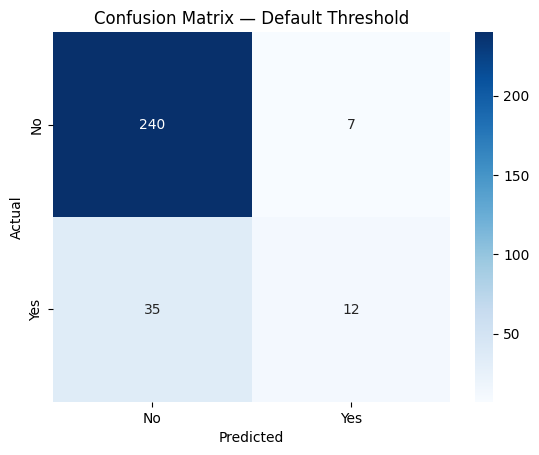

In [82]:
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print("=== Default Threshold (0.5) ===")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix — Default Threshold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Best threshold: 0.2450
Best F1 at this threshold: 0.5370


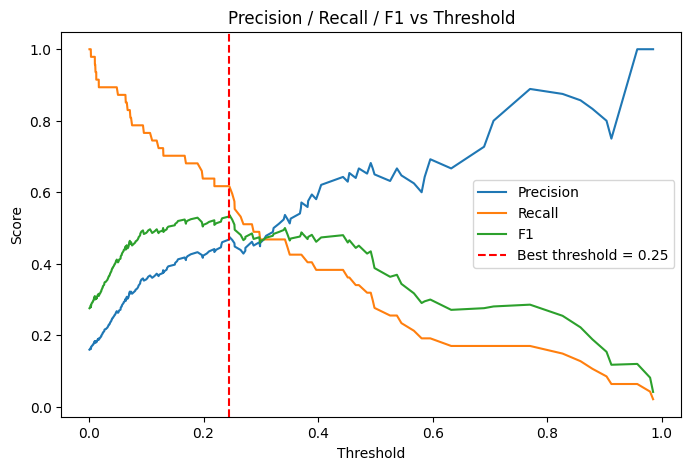

In [83]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold that maximizes F1 for attrition class
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1 at this threshold: {f1_scores[best_idx]:.4f}")

# Plot precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.show()

=== Optimal Threshold (0.2450) ===
              precision    recall  f1-score   support

No Attrition       0.92      0.87      0.90       247
   Attrition       0.48      0.62      0.54        47

    accuracy                           0.83       294
   macro avg       0.70      0.74      0.72       294
weighted avg       0.85      0.83      0.84       294

ROC-AUC: 0.8064


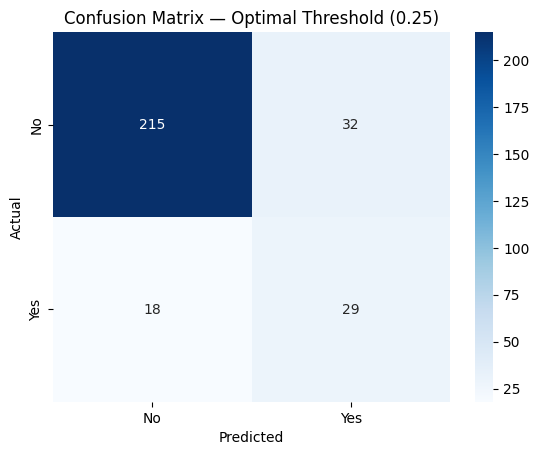

In [84]:
y_pred_optimal = (y_proba >= best_threshold).astype(int)

print(f"=== Optimal Threshold ({best_threshold:.4f}) ===")
print(classification_report(y_test, y_pred_optimal, target_names=['No Attrition', 'Attrition']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

cm2 = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix — Optimal Threshold ({best_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [85]:
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'shap'], returncode=0, stdout=b'Requirement already satisfied: shap in C:\\Users\\Deepshikha\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages (0.51.0)\r\nRequirement already satisfied: numpy>=2 in C:\\Users\\Deepshikha\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages (from shap) (2.4.6)\r\nRequirement already satisfied: scipy in C:\\Users\\Deepshikha\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages (from shap) (1.17.1)\r\nRequirement already satisfied: scikit-learn in C:\\Users\\Deepshikha\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages (from shap) (1.8.0)\r\nRequirement already satisfied: pandas in C:\\Users\\Deepshikha\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages (from shap) (3.0.3)\r\nRequirement already satisfied: tqdm>=4.27.0 in C:\\Users\\Deepshikha\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages (from shap) (4.67.3)\r\nRequirement already satis

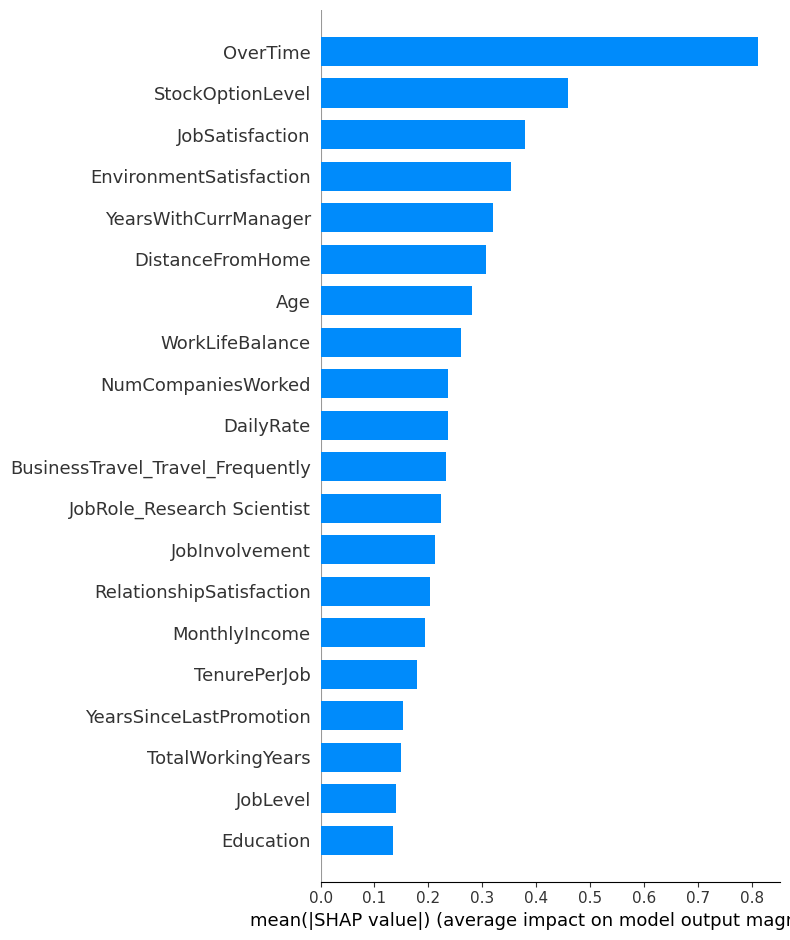

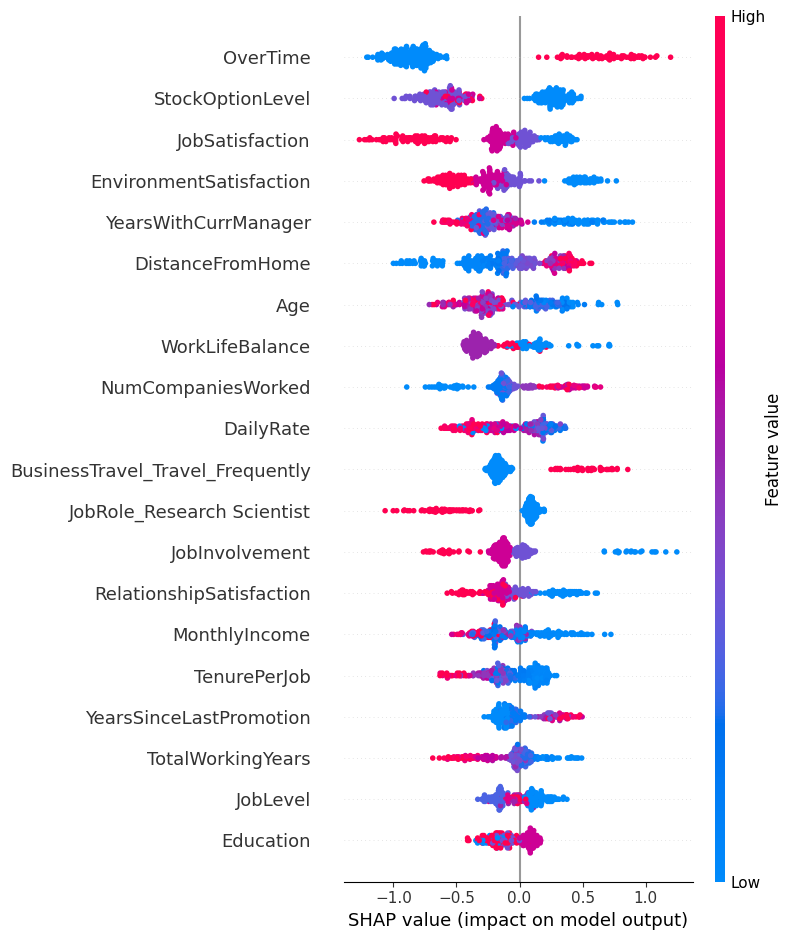

In [86]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type='bar', show=True)

# Detailed SHAP plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=True)

In [87]:
import pickle

pickle.dump(xgb, open('../artifacts/xgboost_model.pkl', 'wb'))
pickle.dump(best_threshold, open('../artifacts/threshold.pkl', 'wb'))

print("Model saved successfully")

Model saved successfully


In [88]:
pickle.dump(xgb, open('../artifacts/xgboost_model.pkl', 'wb'))
pickle.dump(best_threshold, open('../artifacts/threshold.pkl', 'wb'))
